# Exploratory Data Analysis and Data Visualization

This notebook explores behavior patterns in the dataset, including univariate, Bivariate, covariate analysis and interactions, timebased analysis. The final step exports an EDA-ready dataset for future analysis.


## Dataset Loading and Overview

**Purpose:** Load the cleaned dataset and understand its structure

**Initial Checks:**
- Dataset shape and size
- Column names and data types
- Basic statistics
- Data quality summary
- Memory usage

**This section establishes the foundation for all subsequent analysis**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")


sns.set(style="whitegrid", palette="muted", font_scale=1.3)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

In [2]:
df = pd.read_csv(r"e:/dm4ml project/data/processed/final_dataset_cleaned.csv")
df.head()

,user_id,product_id,interaction_type,user_rating,timestamp,id,title,description,category,price,...,weight_normalized,user_rating_normalized,product_rating_normalized,price_standardized,discount_standardized,stock_standardized,weight_standardized,price_category,discount_category,product_rating_category
0,694,10,click,3,2026-04-12 21:17:02.980005,10,gucci bloom eau de,gucci bloom by gucci is a floral and captivati...,fragrances,79.99,...,0.666667,0.50,0.087500,-0.250368,0.852079,1.074345,0.380121,Mid-range,Low,Average
1,2276,6,click,4,2026-04-07 21:17:02.987003,6,calvin klein ck one,ck one by calvin klein is a classic unisex fra...,fragrances,49.99,...,0.666667,0.75,0.766667,-0.303623,-1.455666,-0.792873,0.380121,Budget,Low,Excellent
2,4642,24,purchase,4,2026-03-24 21:17:02.986514,24,fish steak,quality fish steak suitable for grilling bakin...,groceries,14.99,...,0.555556,0.75,0.520833,-0.365753,-1.023656,0.562366,0.065521,Budget,Low,Good
3,3016,28,click,1,2026-03-20 21:17:02.981622,28,ice cream,creamy and delicious ice cream available in va...,groceries,5.49,...,0.000000,0.00,0.358333,-0.382617,-0.200253,-0.853106,-1.507482,Budget,Low,Good
4,8246,27,click,3,2026-03-17 21:17:02.983616,27,honey jar,pure and natural honey in a convenient jar per...,groceries,6.99,...,0.111111,0.50,0.600000,-0.379954,0.853925,-0.642291,-1.192882,Budget,Low,Good


In [3]:
print(f"\n Dataset shape: {df.shape}")
print(f" records: {len(df):,}")
print(f" features: {len(df.columns):,}")


 Dataset shape: (26250, 53)
 records: 26,250
 features: 53


In [4]:
print("Missing valies:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✓ No missing values found")
else:
    print(missing[missing > 0])

Missing valies:
brand    12979
dtype: int64


In [5]:
df.describe()

,user_id,product_id,user_rating,id,price,discountPercentage,product_rating,stock,weight,minimumOrderQuantity,...,price_normalized,discount_normalized,stock_normalized,weight_normalized,user_rating_normalized,product_rating_normalized,price_standardized,discount_standardized,stock_standardized,weight_standardized
count,26250.000000,26250.000000,26250.000000,26250.000000,26250.000000,26250.000000,26250.000000,26250.000000,26250.000000,26250.000000,...,26250.000000,26250.000000,26250.000000,26250.000000,26250.000000,26250.000000,2.625000e+04,2.625000e+04,2.625000e+04,2.625000e+04
mean,4935.171200,15.420533,3.010476,15.420533,221.030244,9.774678,3.869108,55.326933,5.791733,21.376610,...,0.088051,0.507907,0.545072,0.532415,0.502619,0.557962,1.613270e-16,1.385897e-16,-1.001527e-16,-1.461688e-17
std,2905.762893,8.615474,1.424361,8.615474,563.342409,5.416647,0.697102,33.205110,3.178694,17.194615,...,0.225427,0.286141,0.345887,0.353188,0.356090,0.290459,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,1.000000,1.000000,1.000000,1.000000,0.990000,0.160000,2.530000,3.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.906051e-01,-1.775058e+00,-1.575900e+00,-1.507482e+00
25%,2390.000000,8.000000,2.000000,8.000000,4.990000,8.570000,3.250000,27.000000,2.000000,3.000000,...,0.001601,0.444268,0.250000,0.111111,0.250000,0.300000,-3.835045e-01,-2.224071e-01,-8.531058e-01,-1.192882e+00
50%,4948.000000,15.000000,3.000000,15.000000,12.990000,10.270000,3.960000,60.000000,6.000000,22.000000,...,0.004802,0.534073,0.593750,0.555556,0.500000,0.595833,-3.693033e-01,9.144619e-02,1.407360e-01,6.552082e-02
75%,7454.000000,23.000000,4.000000,23.000000,79.990000,14.390000,4.370000,88.000000,9.000000,40.000000,...,0.031613,0.751717,0.885417,0.888889,0.750000,0.766667,-2.503680e-01,8.520789e-01,9.839958e-01,1.009323e+00
max,10000.000000,30.000000,5.000000,30.000000,2499.990000,19.090000,4.930000,99.000000,10.000000,50.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.045503e+00,1.719791e+00,1.315276e+00,1.323923e+00


## Univariate Analysis: Numerical Features

**Purpose:** Understand distribution and characteristics of individual numerical variables

**Analysis Includes:**
- Histogram with KDE (Kernel Density Estimation)
- Box plots (to identify outliers)
- Summary statistics (mean, median, std dev, skewness, kurtosis)
- Distribution shape assessment (normal, skewed, bimodal)

**Numerical Features to Analyze:**
- price, discountPercentage, stock, weight, user_rating, product_rating

**Key Metrics:**
- Mean: Central tendency
- Median: Middle value (robust to outliers)
- Std Dev: Data spread
- Skewness: Asymmetry (-1 to 1: normal, >1: right-skewed, <-1: left-skewed)
- Kurtosis: Tail heaviness

In [6]:
numerical_cols = ['price', 'discountPercentage', 'stock', 'weight', 'user_rating', 'product_rating']

print("Univariate Analysis:")

#Detailed statistics for numerical columns includes skewness and kurtosis
for col in numerical_cols:
    print(f"\n{col.upper()}:")
    print(f"  Count: {df[col].count():,}")
    print(f"  Mean: {df[col].mean():.4f}")
    print(f"  Median: {df[col].median():.4f}")
    print(f"  Std Dev: {df[col].std():.4f}")
    print(f"  Min: {df[col].min():.4f}")
    print(f"  Max: {df[col].max():.4f}")
    print(f" Skewness: {stats.skew(df[col]):.4f}")
    print(f" Kurtosis: {stats.kurtosis(df[col]):.4f}")


Univariate Analysis:

PRICE:
  Count: 26,250
  Mean: 221.0302
  Median: 12.9900
  Std Dev: 563.3424
  Min: 0.9900
  Max: 2499.9900
 Skewness: 3.1133
 Kurtosis: 8.6447

DISCOUNTPERCENTAGE:
  Count: 26,250
  Mean: 9.7747
  Median: 10.2700
  Std Dev: 5.4166
  Min: 0.1600
  Max: 19.0900
 Skewness: -0.4387
 Kurtosis: -0.7692

STOCK:
  Count: 26,250
  Mean: 55.3269
  Median: 60.0000
  Std Dev: 33.2051
  Min: 3.0000
  Max: 99.0000
 Skewness: -0.1996
 Kurtosis: -1.4332

WEIGHT:
  Count: 26,250
  Mean: 5.7917
  Median: 6.0000
  Std Dev: 3.1787
  Min: 1.0000
  Max: 10.0000
 Skewness: -0.1572
 Kurtosis: -1.3235

USER_RATING:
  Count: 26,250
  Mean: 3.0105
  Median: 3.0000
  Std Dev: 1.4244
  Min: 1.0000
  Max: 5.0000
 Skewness: -0.0129
 Kurtosis: -1.3179

PRODUCT_RATING:
  Count: 26,250
  Mean: 3.8691
  Median: 3.9600
  Std Dev: 0.6971
  Min: 2.5300
  Max: 4.9300
 Skewness: -0.3518
 Kurtosis: -0.9383


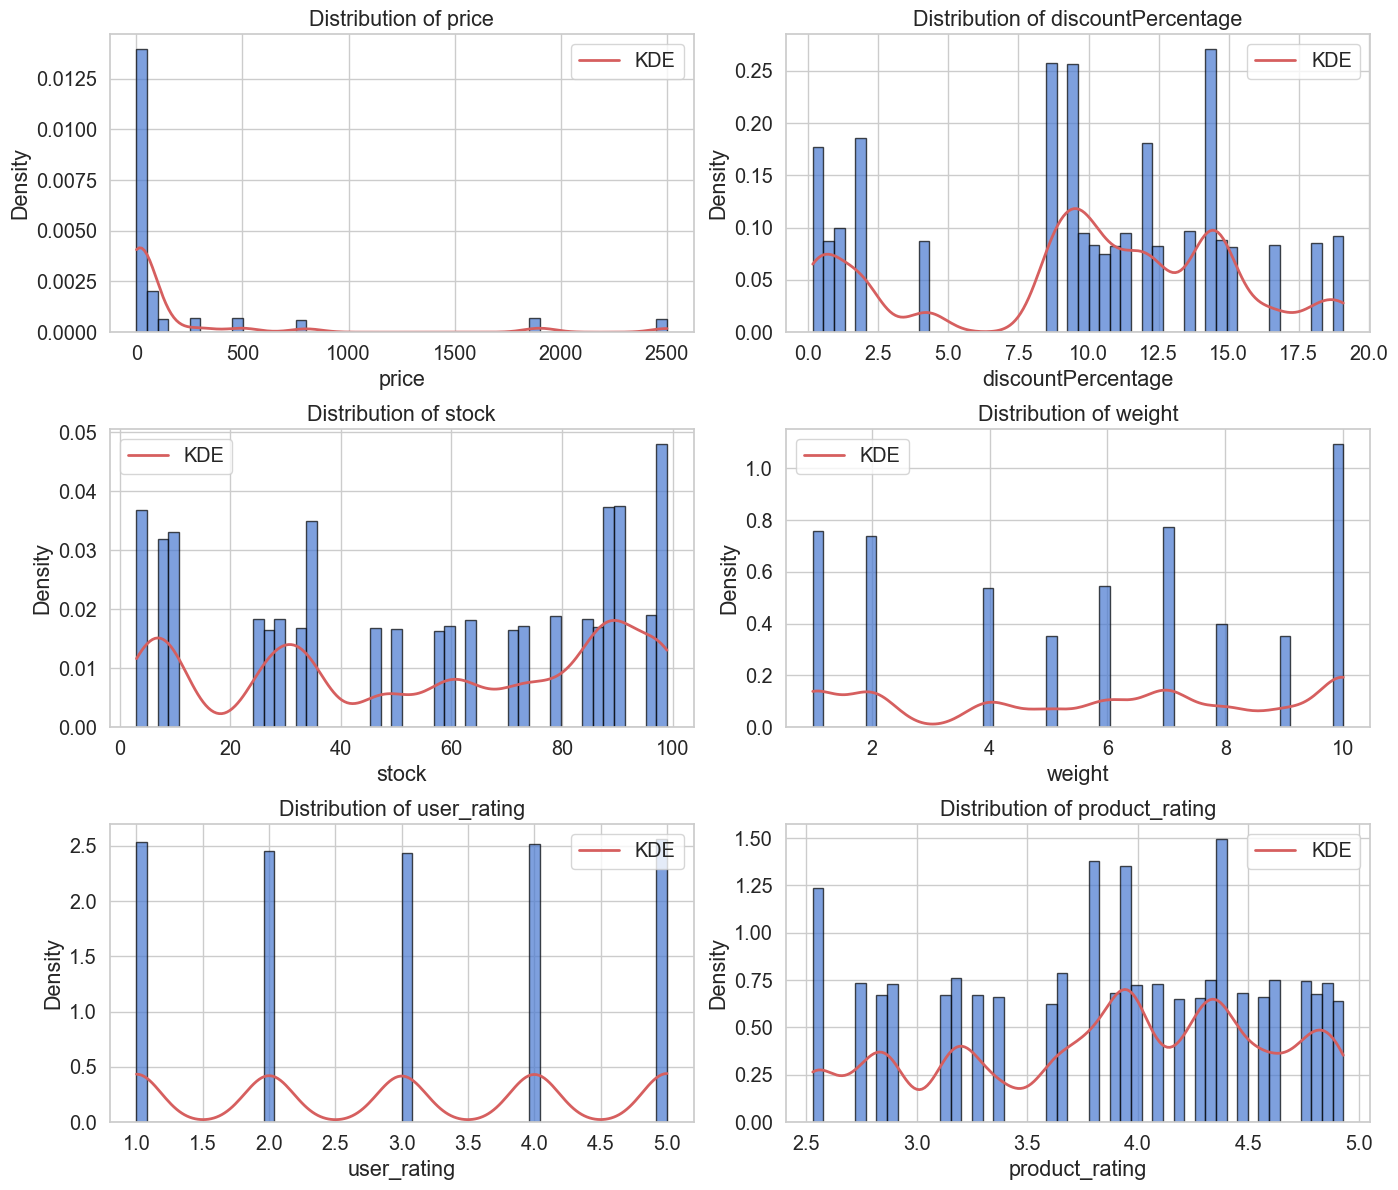

In [7]:
#Distribution plots for numerical columns

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    #Histor plot with KDE
    axes[i].hist(df[col], bins=50, alpha=0.7, edgecolor='black', density=True)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'Distribution of {col}')

    #Add KDE Line
    from scipy.stats import gaussian_kde
    try:
        kde = gaussian_kde(df[col].dropna())
        x_range = np.linspace(df[col].min(), df[col].max(), 200)
        axes[i].plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
        axes[i].legend()

    except Exception as e:
        pass

plt.tight_layout()
plt.show()        

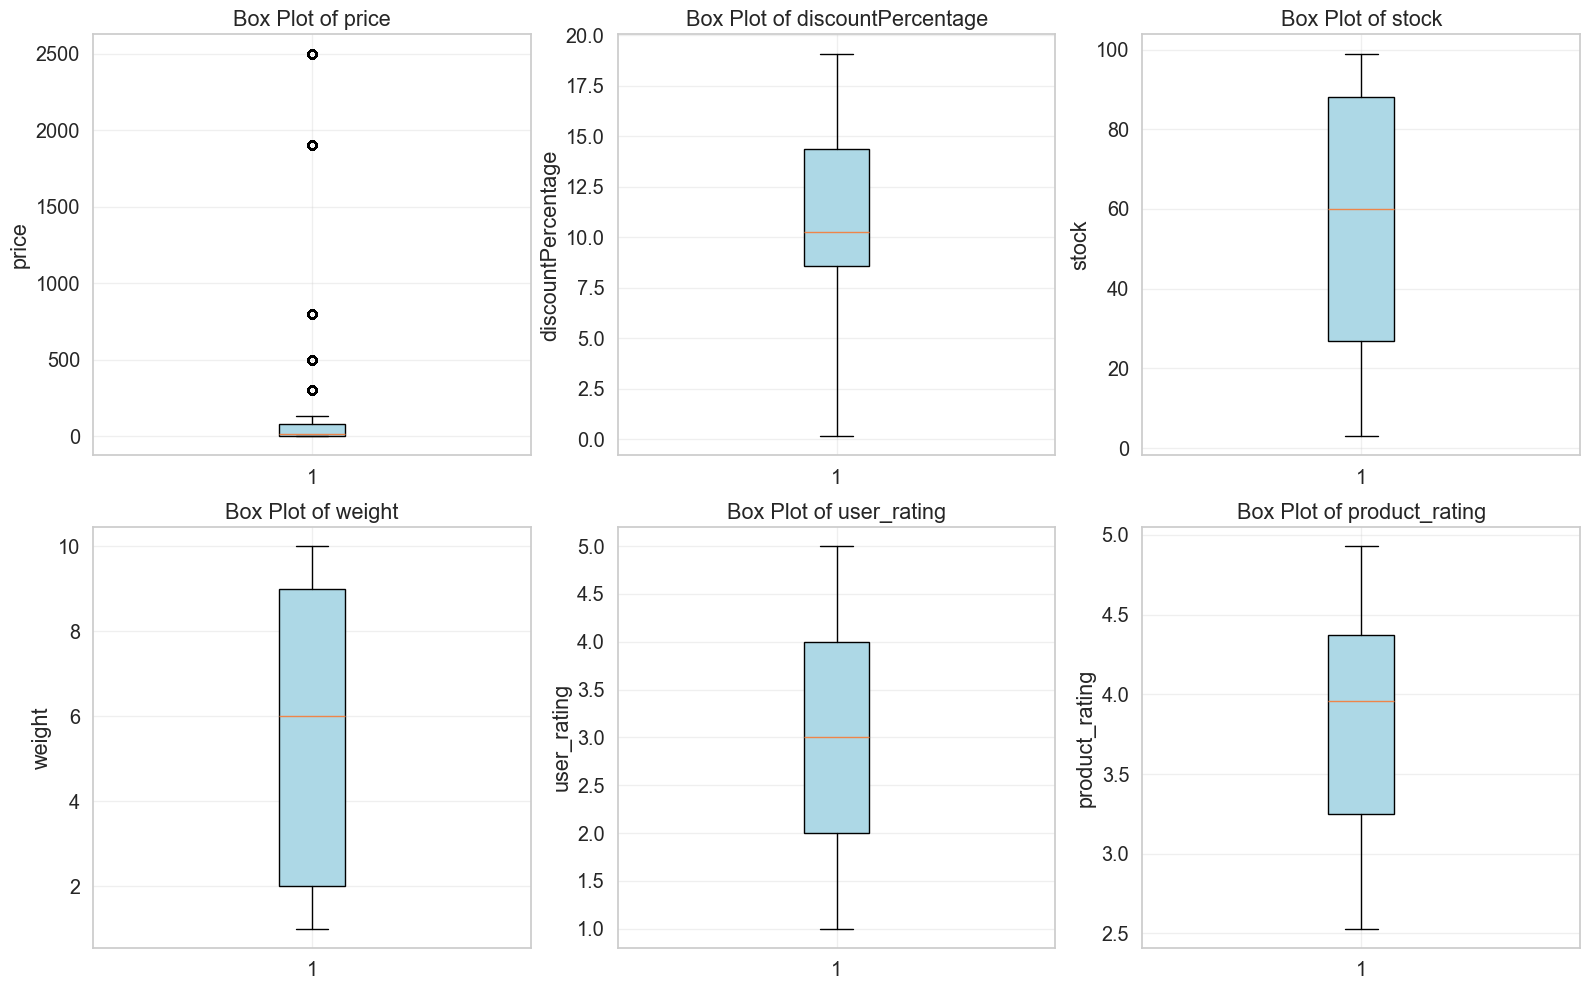

In [9]:
#Box plots for outlier detection

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_ylabel(col)
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Univariate Analysis: Categorical Features

**Purpose:** Understand frequency and distribution of categorical variables

**Analysis Includes:**
- Value counts (frequency distribution)
- Bar charts (visual representation)
- Percentage distribution
- Cardinality (unique values)

**Categorical Features to Analyze:**
- category, interaction_type, brand, availabilityStatus
- price_category, discount_category, product_rating_category, stock_category
- day_period (temporal categorical)

**Insights:**
- Identify dominant categories
- Understand category distribution
- Detect imbalanced categories

In [10]:
# Select categorical columns
categorical_cols = ['category', 'interaction_type', 'brand', 'availabilityStatus']

print("Univariate Analysis - Categorical Features")


for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Missing: {df[col].isnull().sum()}")
        print(f"\n  Value Counts:")
        value_counts = df[col].value_counts()
        for val, count in value_counts.head(10).items():
            percentage = (count / len(df)) * 100
            print(f"    {val}: {count:,} ({percentage:.2f}%)")
        if len(value_counts) > 10:
            print(f"    ... and {len(value_counts) - 10} more categories")


Univariate Analysis - Categorical Features

CATEGORY:
  Unique values: 4
  Missing: 0

  Value Counts:
    groceries: 12,979 (49.44%)
    beauty: 4,438 (16.91%)
    furniture: 4,425 (16.86%)
    fragrances: 4,408 (16.79%)

INTERACTION_TYPE:
  Unique values: 3
  Missing: 0

  Value Counts:
    click: 8,910 (33.94%)
    purchase: 8,696 (33.13%)
    view: 8,644 (32.93%)

BRAND:
  Unique values: 14
  Missing: 12979

  Value Counts:
    annibale colombo: 1,798 (6.85%)
    chic cosmetics: 961 (3.66%)
    nail couture: 945 (3.60%)
    velvet touch: 944 (3.60%)
    calvin klein: 925 (3.52%)
    gucci: 924 (3.52%)
    knoll: 924 (3.52%)
    furniture co.: 917 (3.49%)
    dior: 872 (3.32%)
    dolce & gabbana: 863 (3.29%)
    ... and 4 more categories

AVAILABILITYSTATUS:
  Unique values: 2
  Missing: 0

  Value Counts:
    in stock: 23,610 (89.94%)
    unknown: 2,640 (10.06%)


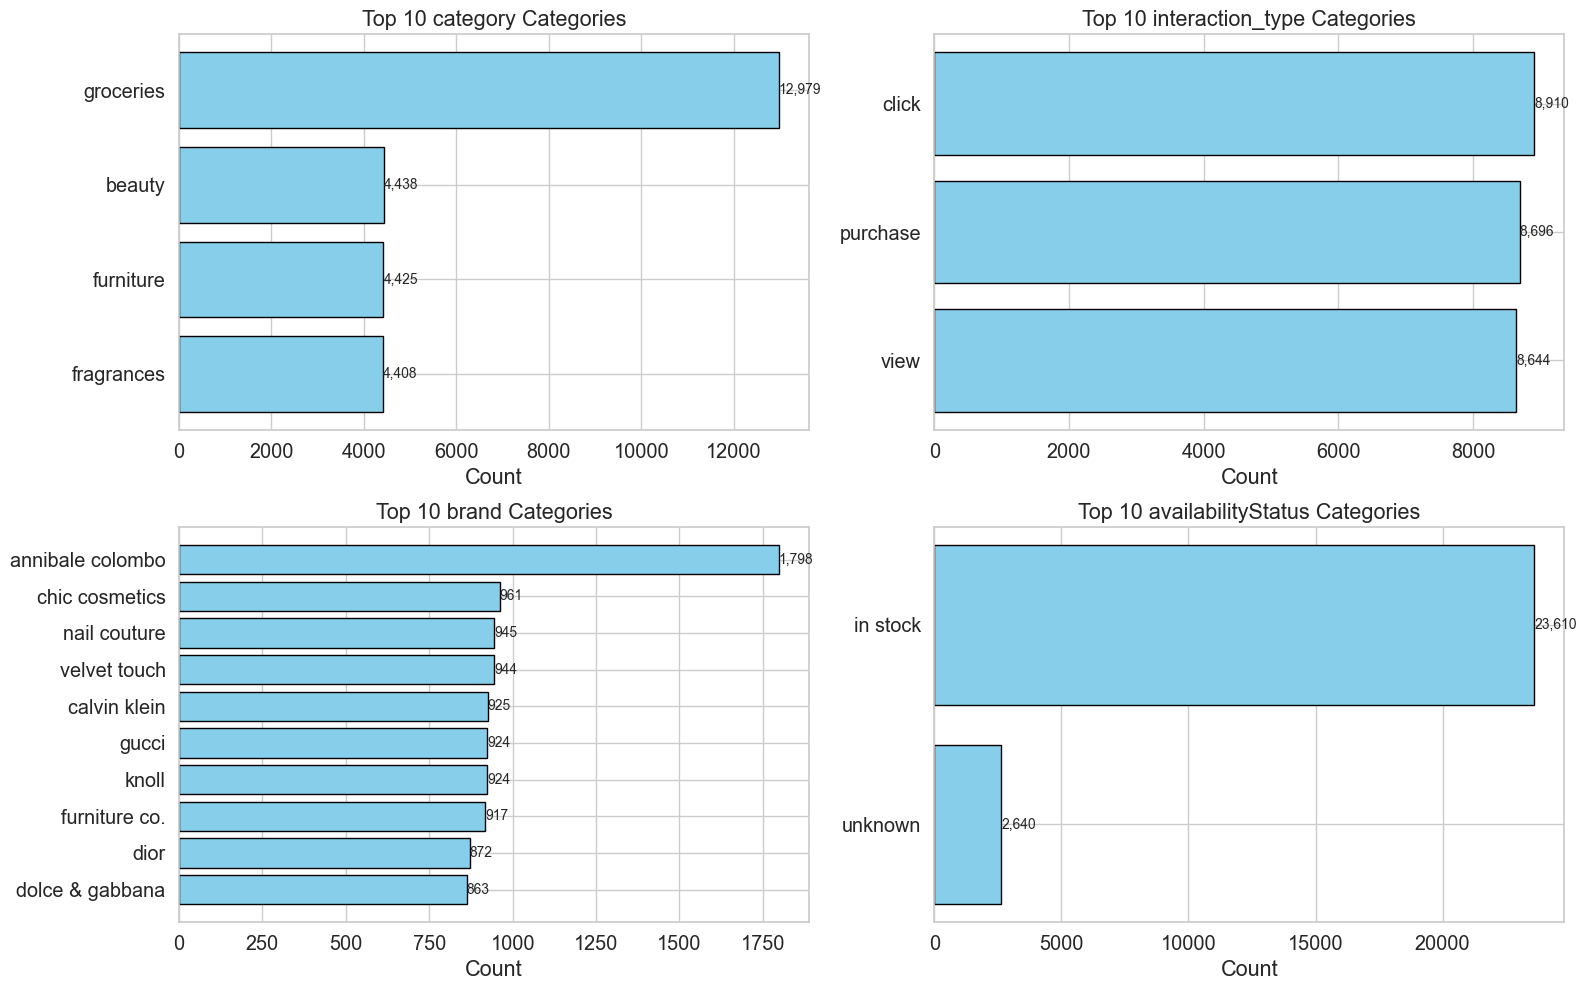

In [11]:
# Visualize top categories
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        value_counts = df[col].value_counts().head(10)
        axes[i].barh(range(len(value_counts)), value_counts.values, color='skyblue', edgecolor='black')
        axes[i].set_yticks(range(len(value_counts)))
        axes[i].set_yticklabels(value_counts.index)
        axes[i].set_xlabel('Count')
        axes[i].set_title(f'Top 10 {col} Categories')
        axes[i].invert_yaxis()

        # add val labels
        for j, val in enumerate(value_counts.values):
            axes[i].text(val, j, f'{val:,}', va='center')

plt.tight_layout()
plt.show()


BINNED CATEGORICAL FEATURES

PRICE_CATEGORY:
price_category
Budget       18342
Luxury        2584
Mid-range     3483
Premium       1841
Name: count, dtype: int64

DISCOUNT_CATEGORY:
discount_category
Low    26250
Name: count, dtype: int64

PRODUCT_RATING_CATEGORY:
product_rating_category
Average       4246
Excellent    11542
Good         10462
Name: count, dtype: int64


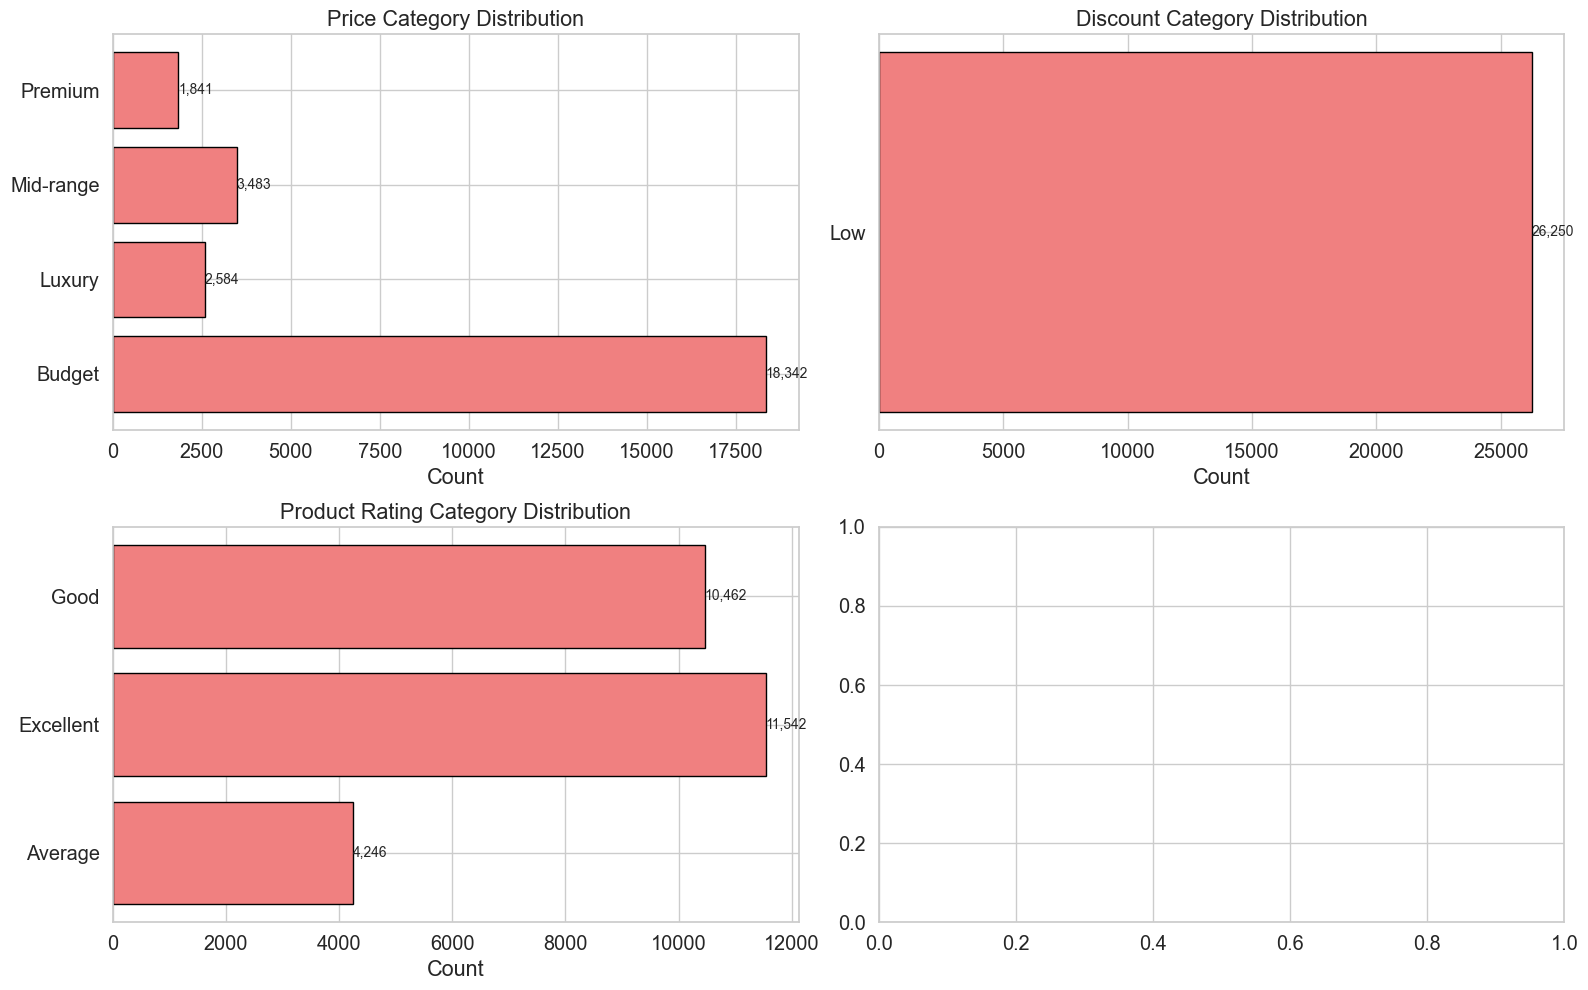

In [12]:
# Binned Categories
binned_cols = ['price_category', 'discount_category', 'product_rating_category', 'stock_category']
print("\n" + "=" * 80)
print("BINNED CATEGORICAL FEATURES")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(binned_cols):
    if col in df.columns:
        value_counts = df[col].value_counts().sort_index()
        print(f"\n{col.upper()}:")
        print(value_counts)

        axes[i].barh(range(len(value_counts)), value_counts.values, color='lightcoral', edgecolor='black')
        axes[i].set_yticks(range(len(value_counts)))
        axes[i].set_yticklabels(value_counts.index)
        axes[i].set_xlabel('Count')
        axes[i].set_title(f'{col.replace("_", " ").title()} Distribution')

        # add val labels
        for j, val in enumerate(value_counts.values):
            axes[i].text(val, j, f'{val:,}', va='center')

plt.tight_layout()
plt.show()

## Bivariate Analysis: Relationships Between Two Variables

**Purpose:** Understand how variables relate to each other

**Analysis Types:**

1. **Numerical vs Numerical:**
   - Scatter plots with regression lines
   - Correlation coefficients (Pearson, Spearman)
   - Joint density plots

2. **Categorical vs Numerical:**
   - Box plots (distribution by category)
   - Violin plots (detailed distribution)
   - Bar plots with error bars (mean ± std)

3. **Categorical vs Categorical:**
   - Crosstabs (contingency tables)
   - Heatmaps (visualization of crosstabs)
   - Grouped bar charts

**Key Questions:**
- Does price correlate with rating?
- Do different categories have different average ratings?
- Is there interaction between discount and purchase behavior?

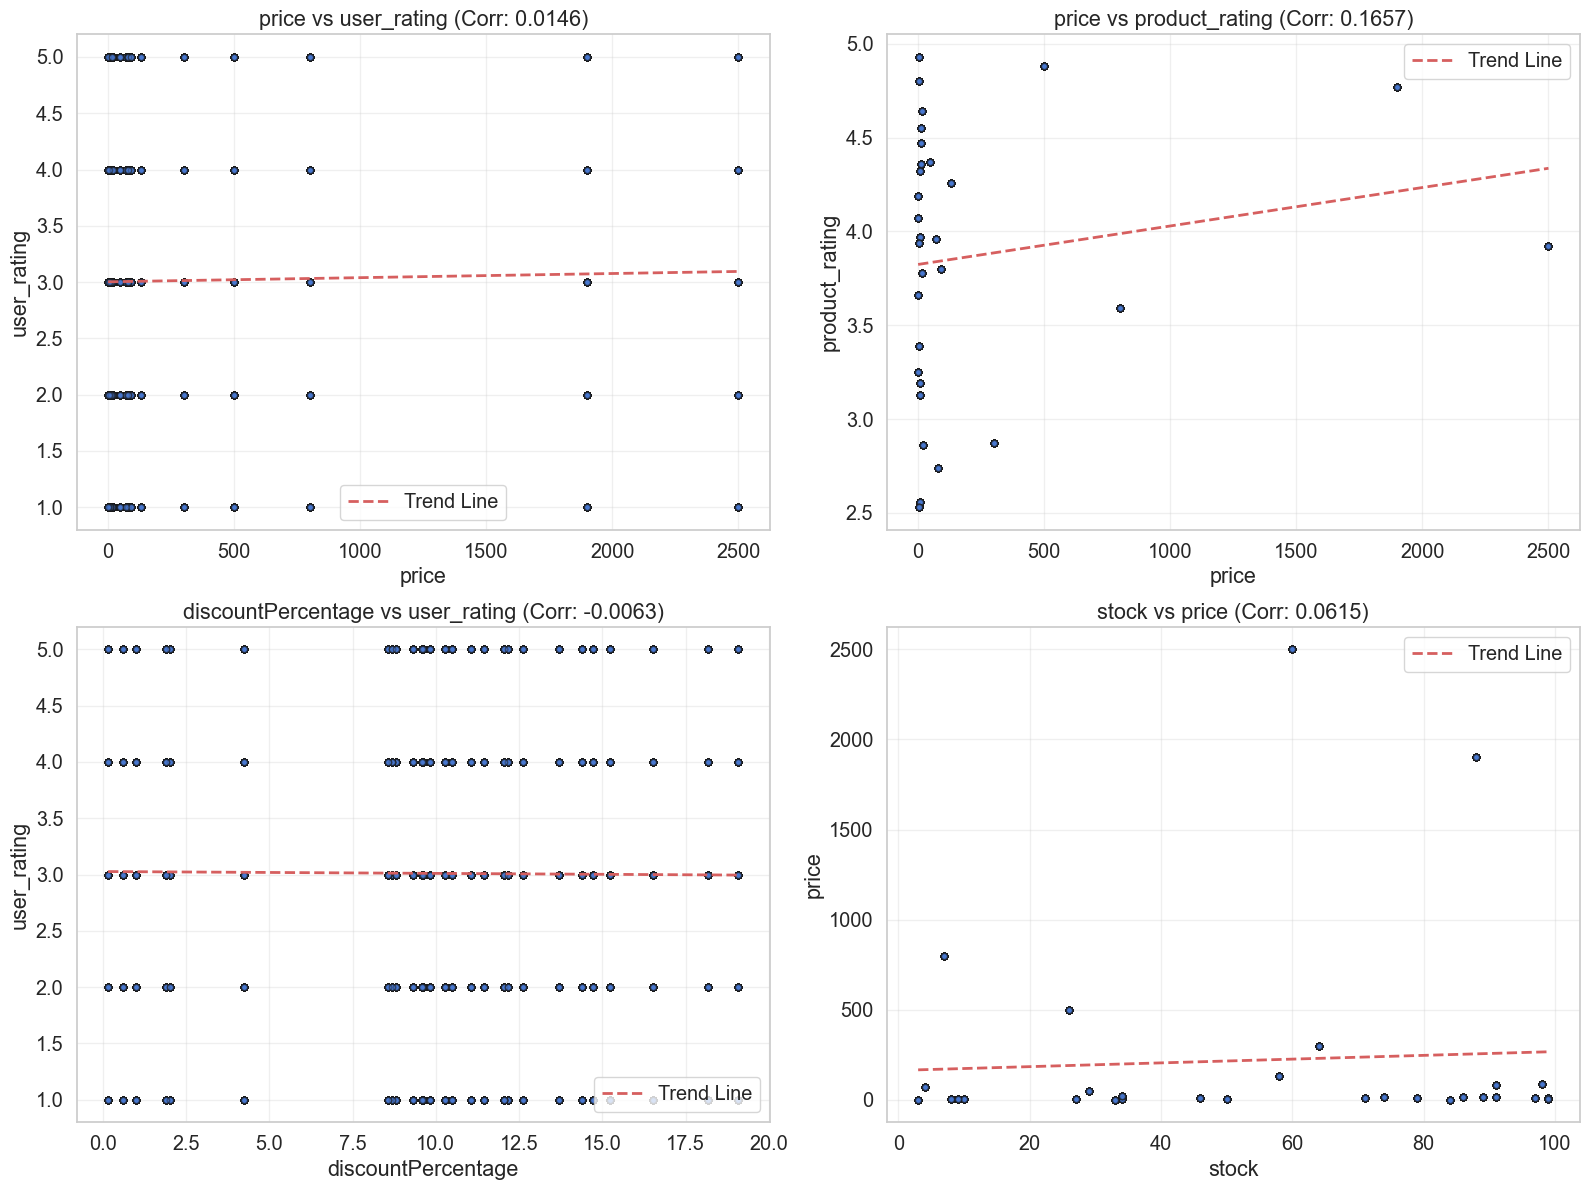

In [13]:
#Selecting numerical pairs for correlation analysis
numerical_pairs = [
    ('price', 'user_rating'),
    ('price', 'product_rating'),
    ('discountPercentage', 'user_rating'),
    ('stock', 'price')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, (col1, col2) in enumerate(numerical_pairs):
    #Scatter plot with regression line
    axes[i].scatter(df[col1], df[col2], alpha=0.5, edgecolor='k', s=20)

    #Add regression line
    z = np.polyfit(df[col1].dropna(), df[col2].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col1].min(), df[col1].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend Line')

    #calculate correlation 
    corr = df[col1].corr(df[col2])

    axes[i].set_xlabel(col1)
    axes[i].set_ylabel(col2)
    axes[i].set_title(f'{col1} vs {col2} (Corr: {corr:.4f})')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

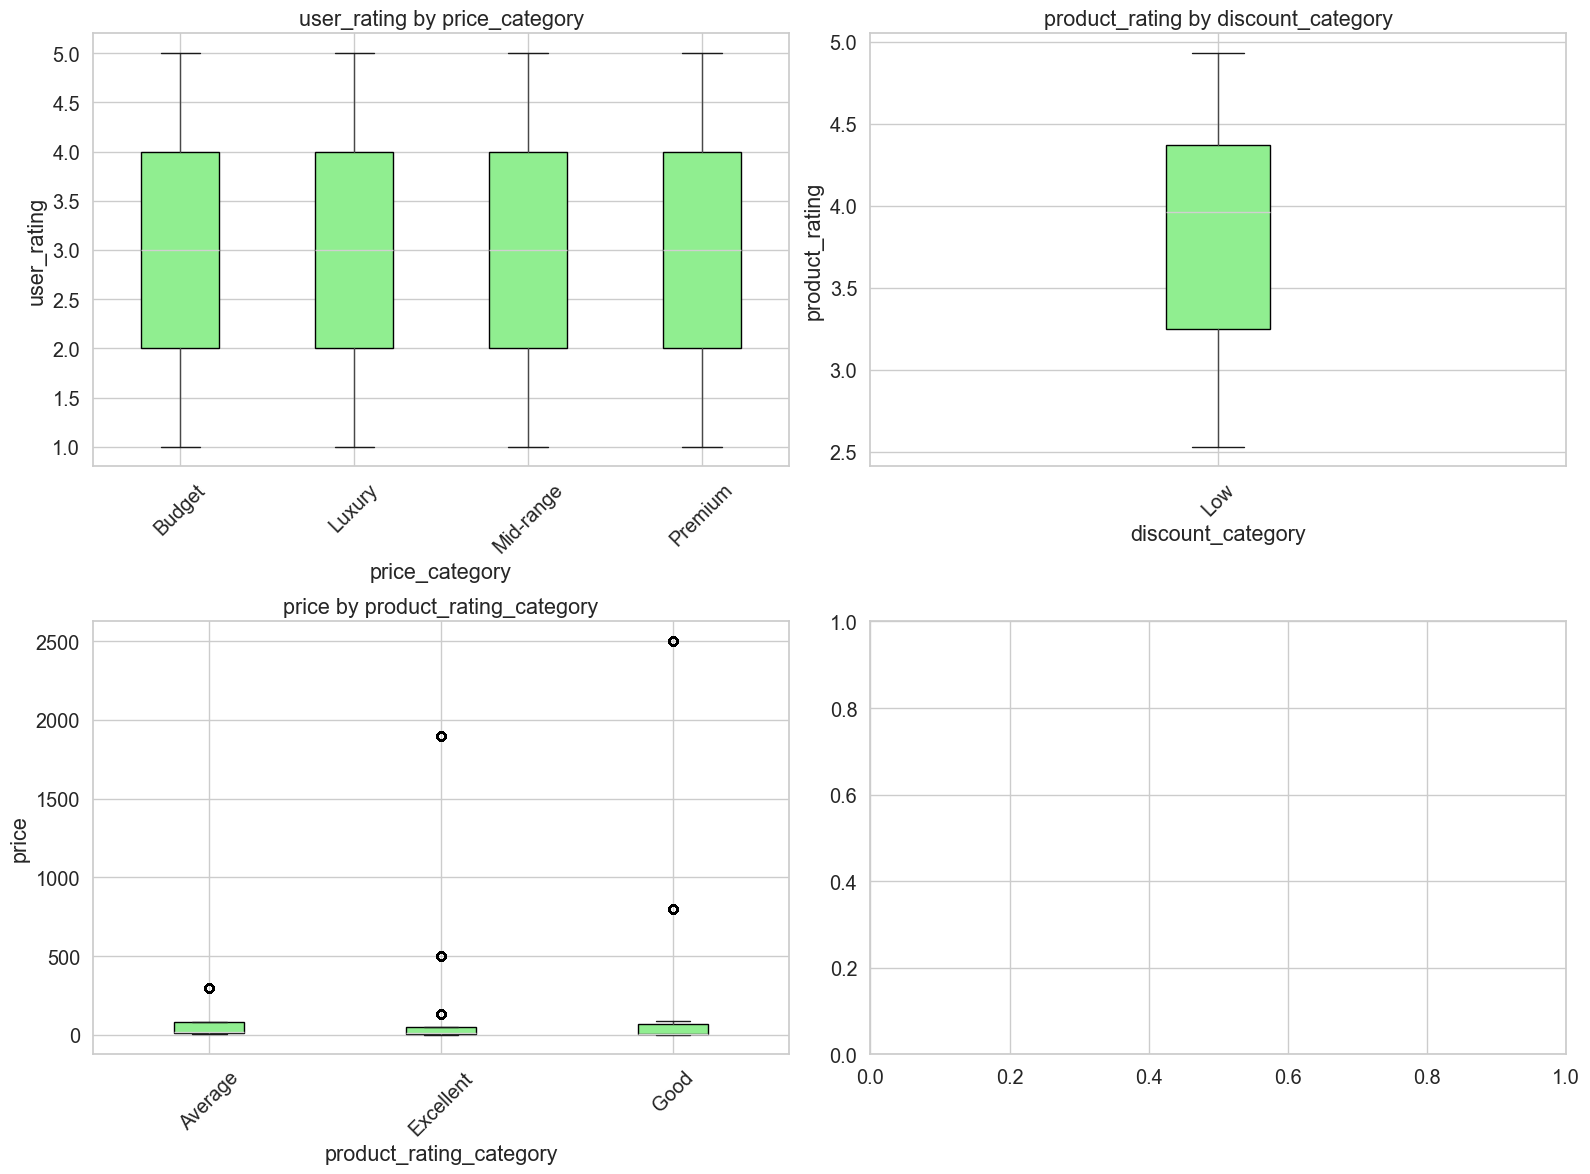

In [14]:
#Numerical vs Categorical Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

categorical_for_analysis = ['price_category', 'discount_category', 'product_rating_category', 'stock_category']
numerical_for_analysis = ['user_rating', 'product_rating', 'price', 'stock']


for i, (cat_col, num_col) in enumerate(zip(categorical_for_analysis, numerical_for_analysis)):
    if cat_col in df.columns:
        #box plot of numerical vs categorical
        df.boxplot(column=num_col, by=cat_col, ax=axes[i], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
        axes[i].set_title(f"{num_col} by {cat_col}")
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        plt.sca(axes[i])
        plt.xticks(rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()


Crosstab of Price Category vs Interaction Type:
interaction_type  click  purchase  view
price_category                         
Budget             6293      6033  6016
Luxury              804       937   843
Mid-range          1136      1158  1189
Premium             677       568   596


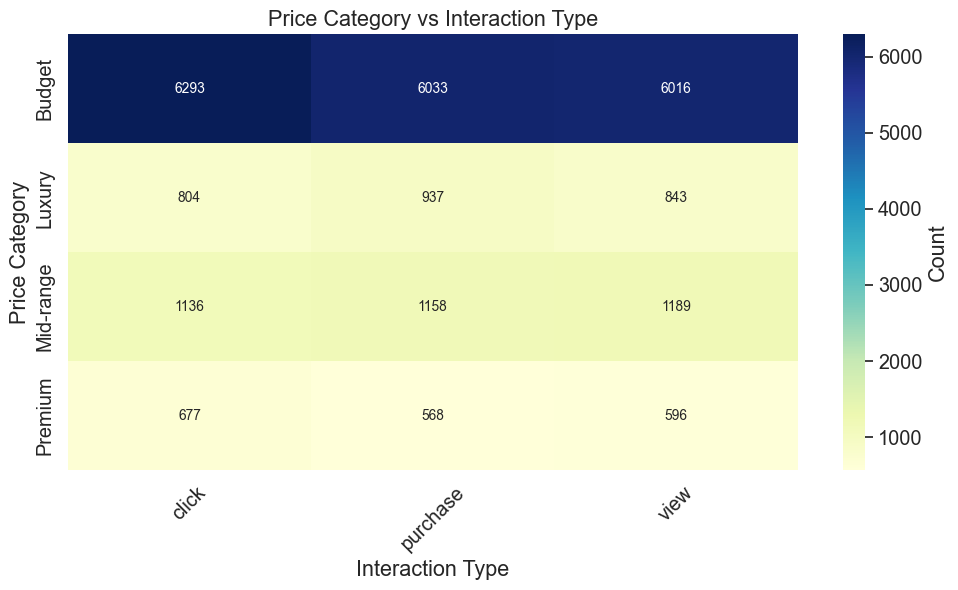

In [15]:
# Categorical vs categorical analysis

if 'price_category' in df.columns and 'interaction_type' in df.columns:
    cross_tab = pd.crosstab(df['price_category'], df['interaction_type'])
    print("\nCrosstab of Price Category vs Interaction Type:")
    print(cross_tab)

    plt.figure(figsize=(10, 6))
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Count'})
    plt.title('Price Category vs Interaction Type')
    plt.xlabel('Interaction Type')
    plt.ylabel('Price Category')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Correlation Analysis

**Purpose:** Identify linear relationships between numerical variables

**Methods:**
1. **Pearson Correlation:** Measures linear relationship (-1 to 1)
   - +1: Perfect positive correlation
   - 0: No correlation
   - -1: Perfect negative correlation

2. **Spearman Correlation:** Measures monotonic relationship (rank-based)
   - Robust to outliers
   - Better for non-linear relationships

3. **Correlation Matrix:** Shows all pairwise correlations

**Interpretation:**
- |r| > 0.7: Strong correlation
- 0.3 < |r| < 0.7: Moderate correlation
- |r| < 0.3: Weak correlation

**Heatmap Visualization:**
- Red: Positive correlation
- Blue: Negative correlation
- Lighter colors: Weaker correlation

In [16]:
# Correlation Matrix Calculation

numerical_col_for_corr = ['price', 'discountPercentage', 'stock', 'weight', 'user_rating', 'product_rating']

#ensure all columns exists

numerical_col_for_corr = [col for col in numerical_col_for_corr if col in df.columns]

correlation_matrix = df[numerical_col_for_corr].corr()
print("\nPearson Correlation Matrix:")
print(correlation_matrix)


Pearson Correlation Matrix:
                       price  discountPercentage     stock    weight  \
price               1.000000            0.085760  0.061520  0.248282   
discountPercentage  0.085760            1.000000  0.354427 -0.142820   
stock               0.061520            0.354427  1.000000 -0.094812   
weight              0.248282           -0.142820 -0.094812  1.000000   
user_rating         0.014559           -0.006255 -0.006296  0.004395   
product_rating      0.165737           -0.219850  0.088186  0.352854   

                    user_rating  product_rating  
price                  0.014559        0.165737  
discountPercentage    -0.006255       -0.219850  
stock                 -0.006296        0.088186  
weight                 0.004395        0.352854  
user_rating            1.000000        0.008648  
product_rating         0.008648        1.000000  



Strong Correlations (|corr| > 0.5):


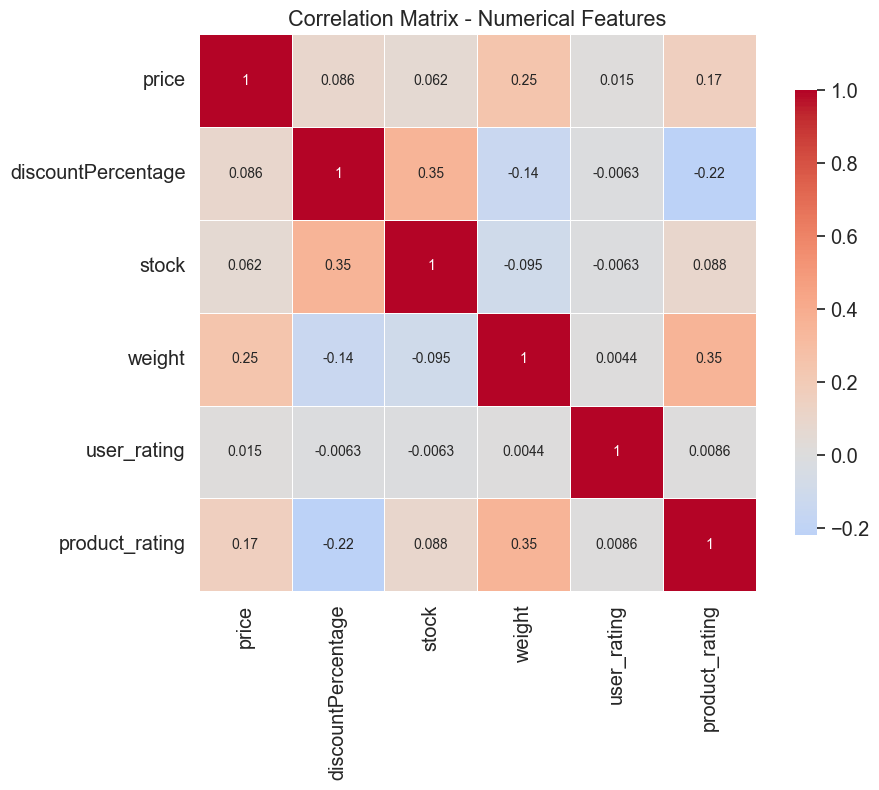

In [18]:
# Finding Strong Correlations
print("\nStrong Correlations (|corr| > 0.5):")
for i in range(len(correlation_matrix.columns)):
    for j  in range(i +1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            print(f"  {col1} and {col2}: {corr_value:.4f}")

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Correlation Matrix - Numerical Features")
plt.tight_layout()
plt.show()

In [19]:
#spearsman correlation for non-parametric data
spearsman_corr = df[numerical_col_for_corr].corr(method='spearman')
print("\nSpearman Correlation Matrix:")
print(spearsman_corr)


Spearman Correlation Matrix:
                       price  discountPercentage     stock    weight  \
price               1.000000            0.226819  0.170949  0.357138   
discountPercentage  0.226819            1.000000  0.402782 -0.190318   
stock               0.170949            0.402782  1.000000 -0.160254   
weight              0.357138           -0.190318 -0.160254  1.000000   
user_rating         0.013131           -0.008891 -0.008279  0.004748   
product_rating      0.075810           -0.182275  0.085639  0.339186   

                    user_rating  product_rating  
price                  0.013131        0.075810  
discountPercentage    -0.008891       -0.182275  
stock                 -0.008279        0.085639  
weight                 0.004748        0.339186  
user_rating            1.000000        0.009271  
product_rating         0.009271        1.000000  


## Distribution Analysis

**Purpose:** Understand how data is distributed across ranges

**Visualizations:**
1. **Histograms:** Raw frequency distribution
2. **KDE (Kernel Density Estimation):** Smooth probability density
3. **CDF (Cumulative Distribution):** Cumulative probability
4. **Q-Q Plots:** Compare against normal distribution

**Questions Answered:**
- Is the data normally distributed?
- Are there multiple peaks (bimodal, multimodal)?
- Where do most values concentrate?
- How do extremes compare?

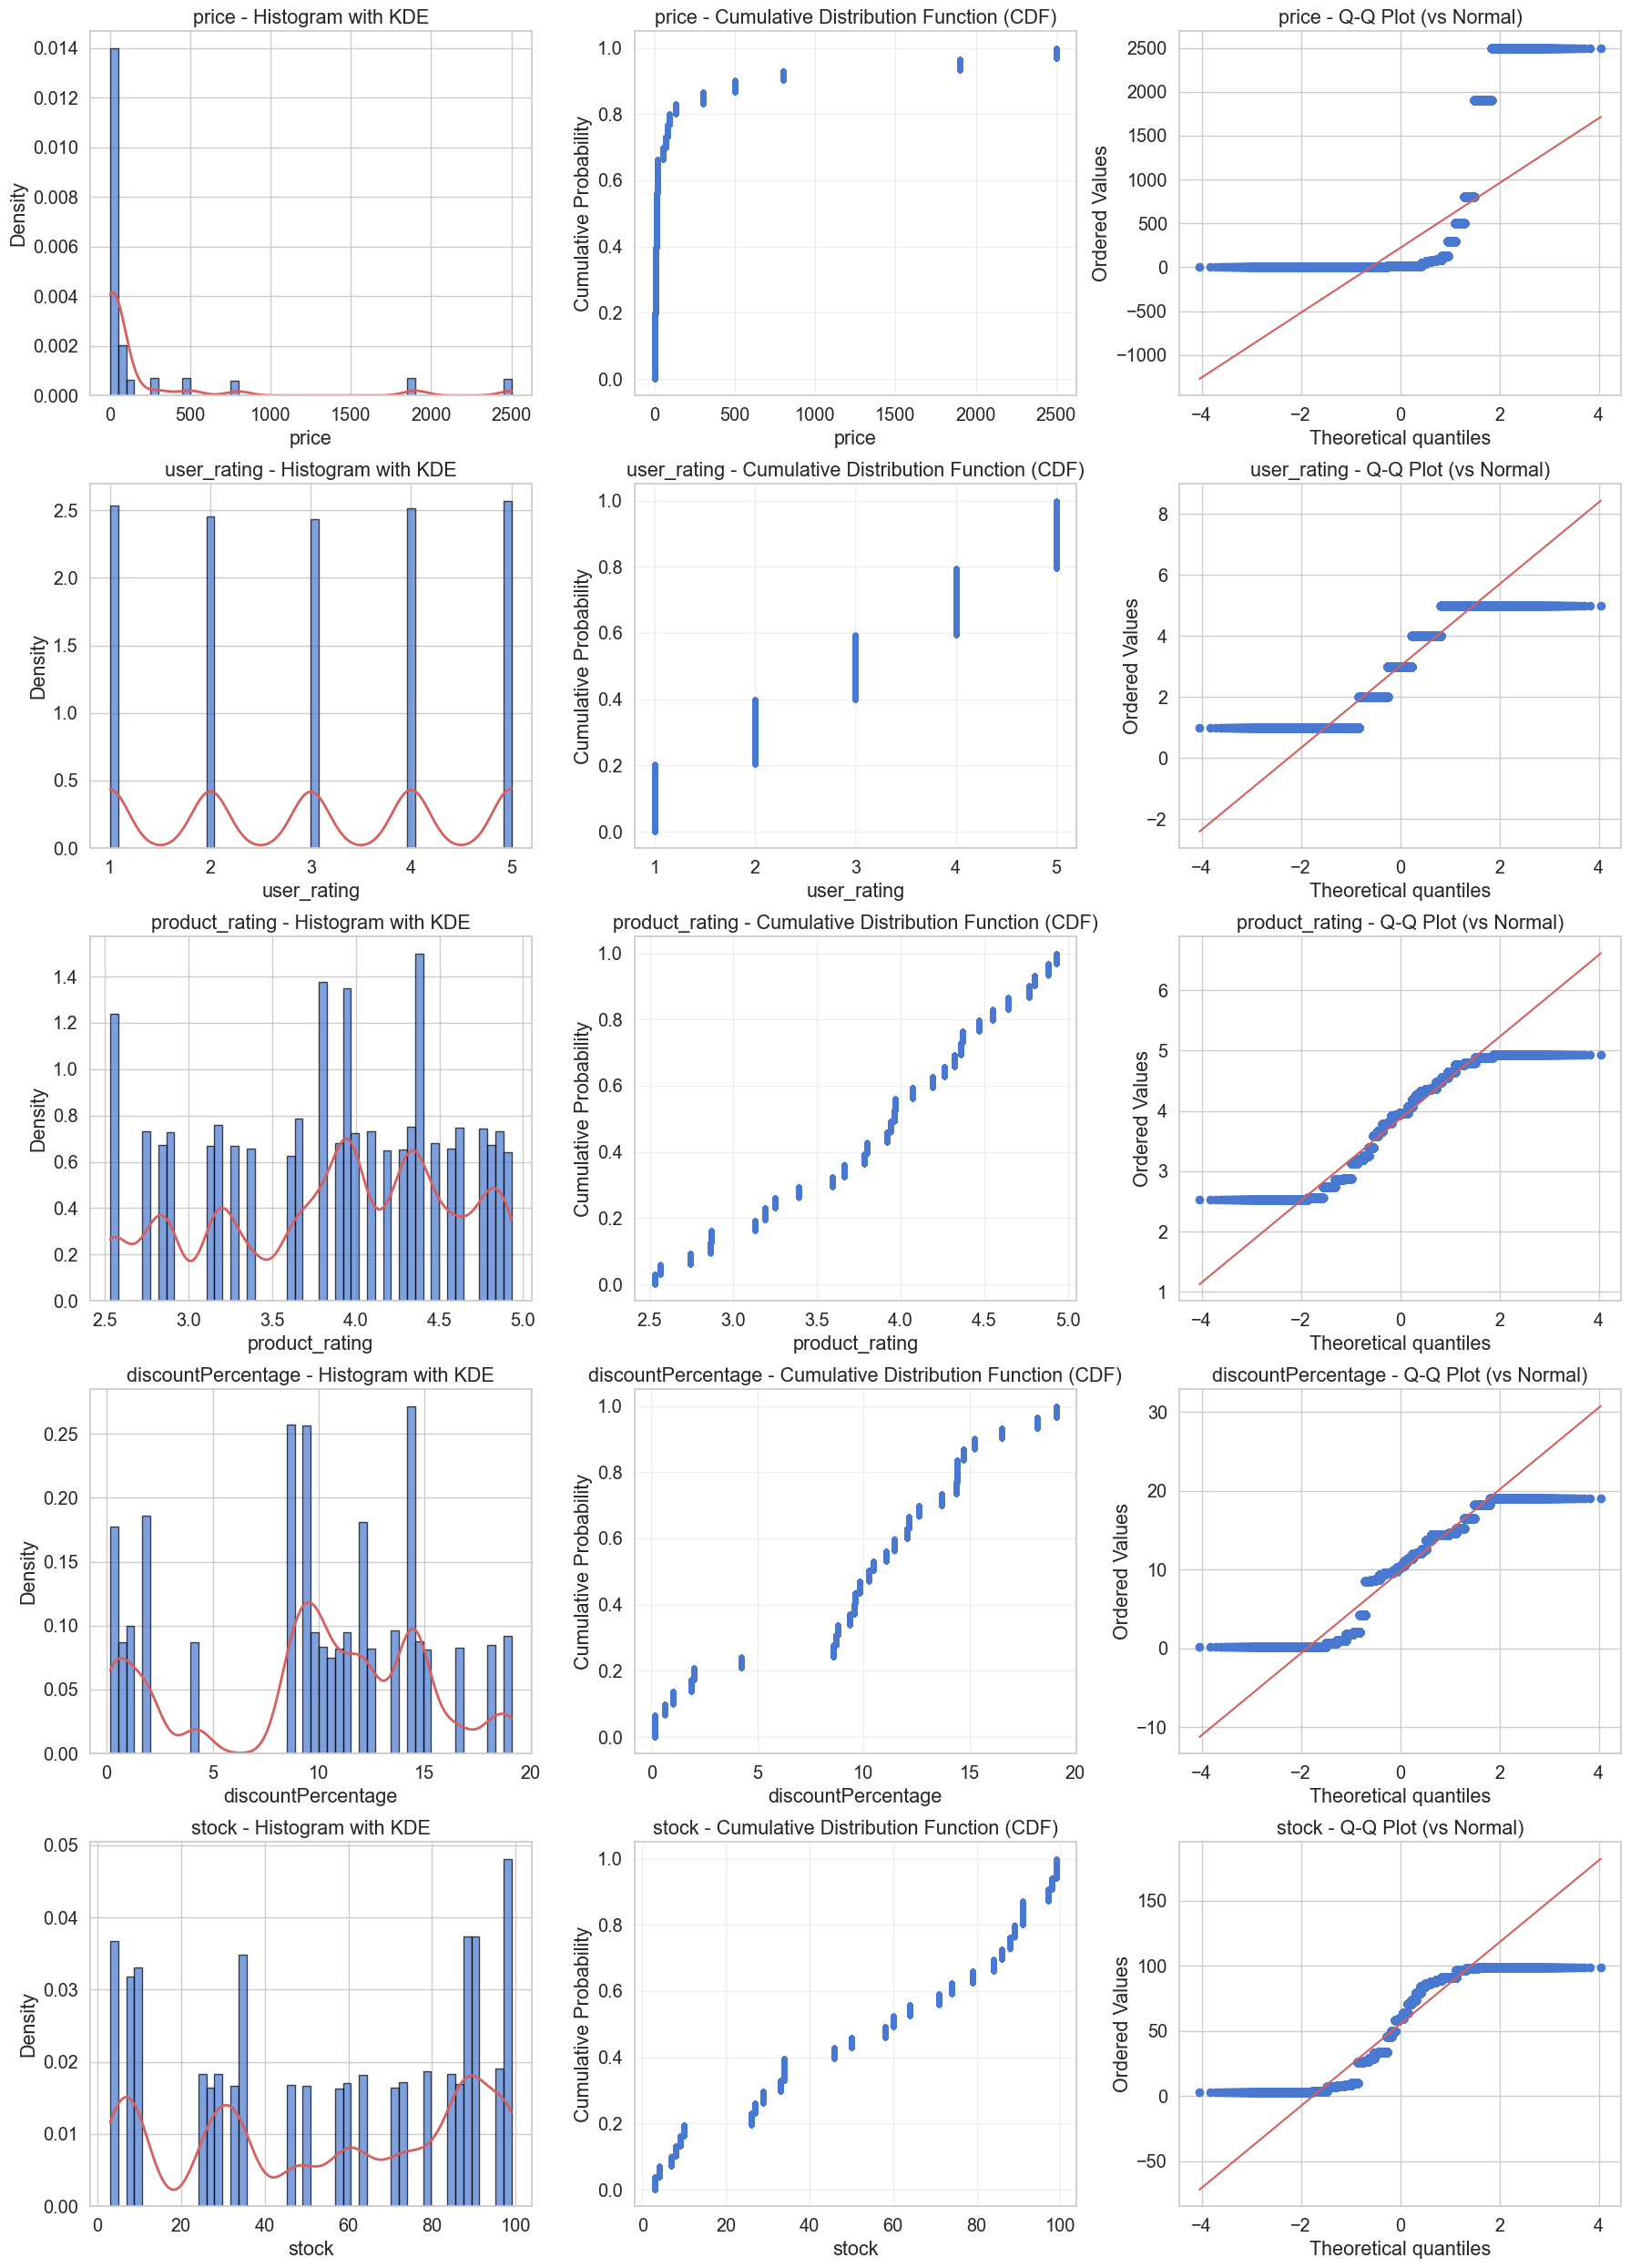

In [21]:
# Detailed Distribution Plots for Numerical Features
numerical_cols = ['price', 'user_rating', 'product_rating', 'discountPercentage', 'stock']
numerical_cols = [col for col in numerical_cols if col in df.columns]

fig, axes = plt.subplots(len(numerical_cols), 3, figsize=(18, 5 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    # Histogram with KDE
    axes[i, 0].hist(df[col], bins=50, alpha=0.7, edgecolor='black', density=True)

    from scipy.stats import gaussian_kde
    try:
        kde = gaussian_kde(df[col].dropna())
        x_range = np.linspace(df[col].min(), df[col].max(), 200)
        axes[i, 0].plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
    except:
        pass

    axes[i, 0].set_title(f'{col} - Histogram with KDE')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Density')

    # CDF
    sorted_data = np.sort(df[col].dropna())
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    axes[i, 1].plot(sorted_data, cdf, marker='.', linestyle='none', linewidth=2)
    axes[i, 1].set_title(f'{col} - Cumulative Distribution Function (CDF)')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Cumulative Probability')
    axes[i, 1].grid(True, alpha=0.3)


    #Q-q Plot (Compare with normal distribution)
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i, 2])
    axes[i, 2].set_title(f'{col} - Q-Q Plot (vs Normal)')

plt.tight_layout()
plt.show()

## Temporal Analysis

**Purpose:** Understand patterns over time

**Temporal Features:**
- hour: Hour of day (0-23)
- day_of_week: Day of week (0-6)
- day_period: Time period (morning, afternoon, evening, night)
- is_weekend: Binary flag

**Analysis:**
- Hourly trends: When is activity peak?
- Daily patterns: Day-to-day variations
- Weekend vs Weekday: Behavior differences
- Time period preferences: When do users interact most?

**Use Case:** Optimize resource allocation, target marketing campaigns, understand user behavior patterns

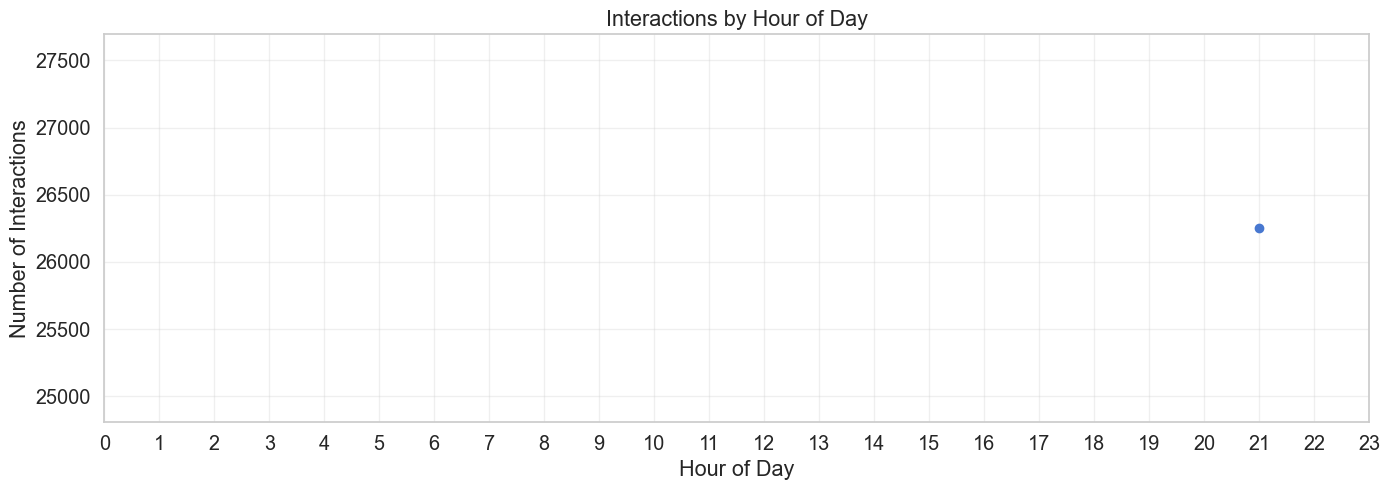


Hourly Distribution:
hour
21    26250
Name: count, dtype: int64


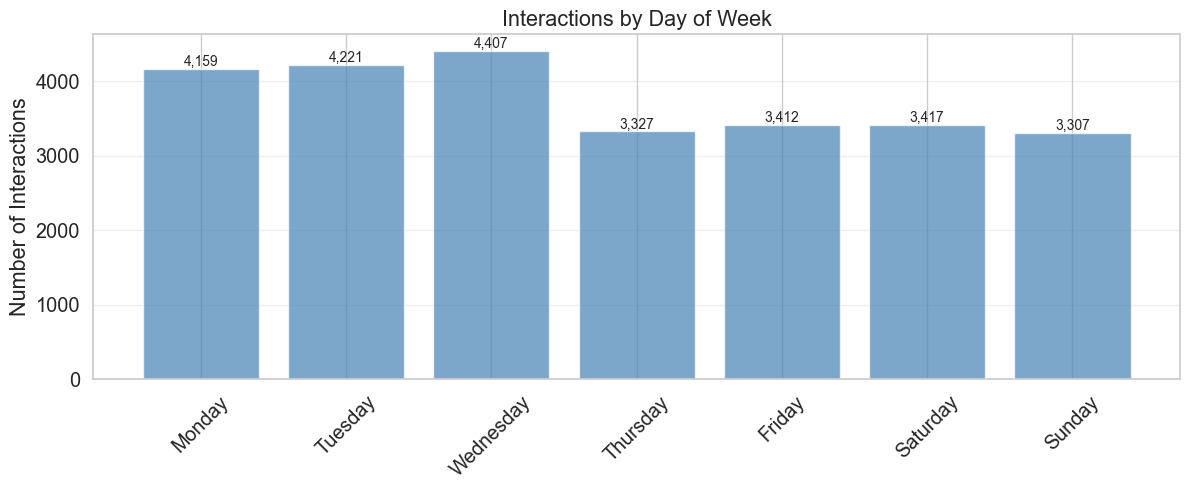


Daily Distribution:
day_of_week
0    4159
1    4221
2    4407
3    3327
4    3412
5    3417
6    3307
Name: count, dtype: int64


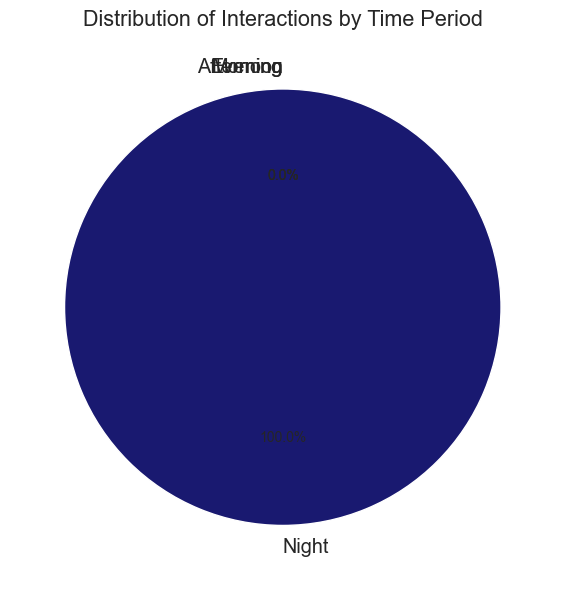


Time Period Distribution:
day_period
Morning          0
Afternoon        0
Evening          0
Night        26250
Name: count, dtype: int64


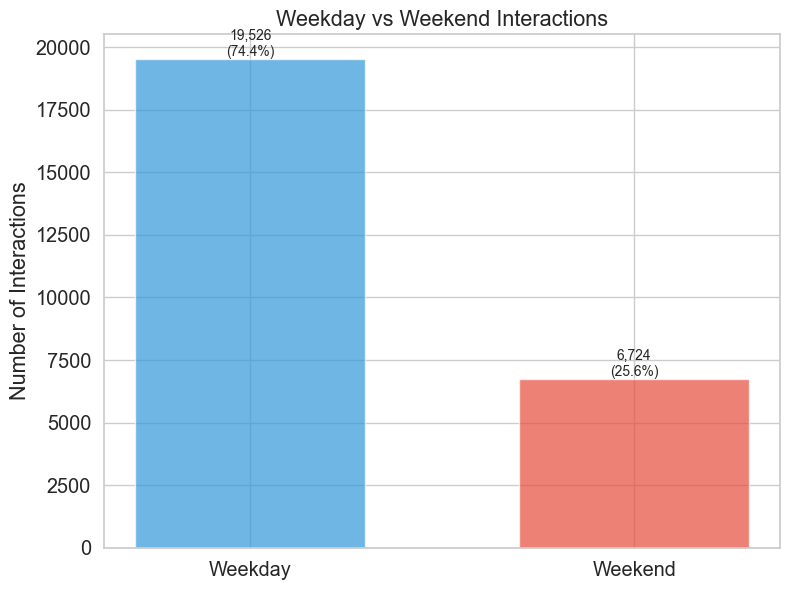

In [22]:
# Check if temporal columns exist
temporal_cols = ['hour', 'day_of_week', 'day_period', 'is_weekend']
temporal_cols = [col for col in temporal_cols if col in df.columns]

if len(temporal_cols) > 0:
    # Hourly analysis
    if 'hour' in df.columns:
        hourly_counts = df['hour'].value_counts().sort_index()
        plt.figure(figsize=(14, 5))
        plt.plot(hourly_counts.index, hourly_counts.values, marker='o', linewidth=2, markersize=6)
        plt.xlabel('Hour of Day')
        plt.ylabel('Number of Interactions')
        plt.title('Interactions by Hour of Day')
        plt.grid(True, alpha=0.3)
        plt.xticks(range(0, 24))
        plt.tight_layout()
        plt.show()
        
        print("\nHourly Distribution:")
        print(hourly_counts)
    
    # Day of week analysis
    if 'day_of_week' in df.columns:
        day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        daily_counts = df['day_of_week'].value_counts().sort_index()
        
        plt.figure(figsize=(12, 5))
        plt.bar(range(len(daily_counts)), daily_counts.values, color='steelblue', alpha=0.7)
        plt.xticks(range(len(daily_counts)), day_names, rotation=45)
        plt.ylabel('Number of Interactions')
        plt.title('Interactions by Day of Week')
        plt.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for i, v in enumerate(daily_counts.values):
            plt.text(i, v, f'{v:,}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        print("\nDaily Distribution:")
        print(daily_counts)
    
    # Day period analysis
    if 'day_period' in df.columns:
        period_counts = df['day_period'].value_counts()
        period_order = ['Morning', 'Afternoon', 'Evening', 'Night']
        period_counts = period_counts.reindex(period_order, fill_value=0)
        
        plt.figure(figsize=(10, 6))
        colors = ['#FFD700', '#FF8C00', '#4169E1', '#191970']
        plt.pie(period_counts.values, labels=period_counts.index, autopct='%1.1f%%', 
                colors=colors, startangle=90)
        plt.title('Distribution of Interactions by Time Period')
        plt.tight_layout()
        plt.show()
        
        print("\nTime Period Distribution:")
        print(period_counts)
    
    # Weekend vs Weekday
    if 'is_weekend' in df.columns:
        weekend_counts = df['is_weekend'].value_counts()
        labels = ['Weekday', 'Weekend']
        values = [weekend_counts.get(0, 0), weekend_counts.get(1, 0)]
        
        plt.figure(figsize=(8, 6))
        bars = plt.bar(labels, values, color=['#3498db', '#e74c3c'], alpha=0.7, width=0.6)
        plt.ylabel('Number of Interactions')
        plt.title('Weekday vs Weekend Interactions')
        
        # Add value labels
        for bar, value in zip(bars, values):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{value:,}\n({value/sum(values)*100:.1f}%)',
                    ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()

## Interaction Type Analysis

**Purpose:** Understand different types of user interactions

**Interaction Types:**
- view: User viewed the product
- cart: User added to cart
- purchase: User completed purchase
- add/remove: Added/removed from wishlist
- other interactions

**Analysis:**
- Frequency of each interaction type
- Conversion funnel (view → cart → purchase)
- Average rating by interaction type
- Price correlation with interaction type

**Business Insight:**
- Understand user behavior journey
- Identify drop-off points in funnel
- Optimize for higher conversions


Interaction Type Distribution:
interaction_type
click       8910
purchase    8696
view        8644
Name: count, dtype: int64


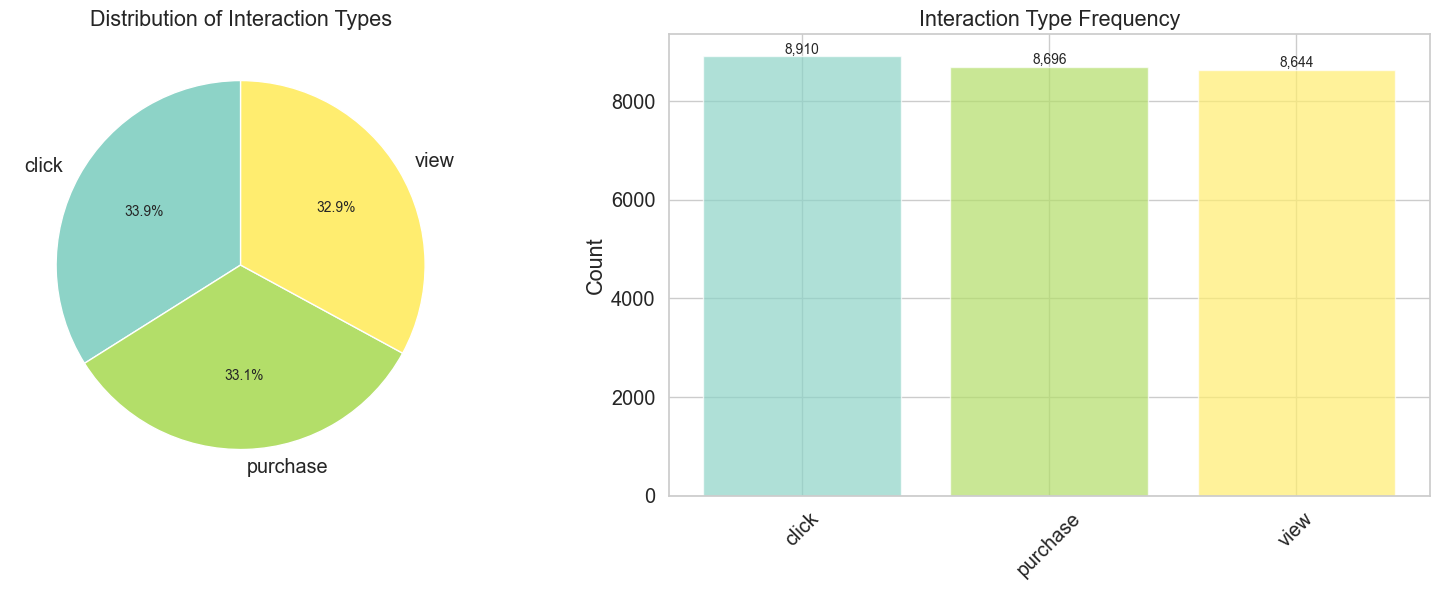


Average Rating by Interaction Type:
                      mean  count       std
interaction_type                           
click             2.984961   8910  1.425675
purchase          3.019549   8696  1.411310
view              3.027649   8644  1.435827


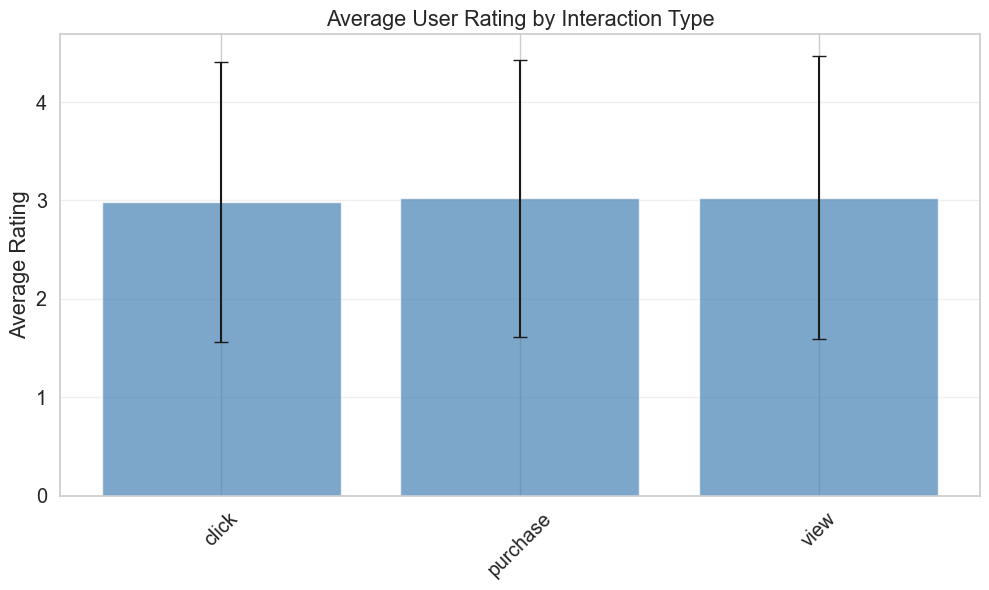

In [23]:
if 'interaction_type' in df.columns:
    # Interaction type distribution
    interaction_counts = df['interaction_type'].value_counts()
    
    print("\nInteraction Type Distribution:")
    print(interaction_counts)
    
    # Pie chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pie chart
    colors = plt.cm.Set3(np.linspace(0, 1, len(interaction_counts)))
    ax1.pie(interaction_counts.values, labels=interaction_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
    ax1.set_title('Distribution of Interaction Types')
    
    # Bar chart
    ax2.bar(range(len(interaction_counts)), interaction_counts.values, color=colors, alpha=0.7)
    ax2.set_xticks(range(len(interaction_counts)))
    ax2.set_xticklabels(interaction_counts.index, rotation=45)
    ax2.set_ylabel('Count')
    ax2.set_title('Interaction Type Frequency')
    
    # Add value labels
    for i, v in enumerate(interaction_counts.values):
        ax2.text(i, v, f'{v:,}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Average rating by interaction type
    if 'user_rating' in df.columns:
        rating_by_interaction = df.groupby('interaction_type')['user_rating'].agg(['mean', 'count', 'std'])
        print("\nAverage Rating by Interaction Type:")
        print(rating_by_interaction)
        
        fig, ax = plt.subplots(figsize=(10, 6))
        x_pos = np.arange(len(rating_by_interaction))
        ax.bar(x_pos, rating_by_interaction['mean'], 
               yerr=rating_by_interaction['std'], capsize=5, 
               alpha=0.7, color='steelblue')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(rating_by_interaction.index, rotation=45)
        ax.set_ylabel('Average Rating')
        ax.set_title('Average User Rating by Interaction Type')
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

## User and Product Analysis

**Purpose:** Understand user behavior and product performance

**User Analysis:**
- Most active users
- Average rating per user
- Purchase frequency
- User segments by activity level

**Product Analysis:**
- Top-rated products
- Best-selling products
- Most viewed products
- Product diversity (categories)

**Insights:**
- Identify power users
- Recognize high-value products
- Understand product preferences
- Segment users for targeting


Top 10 Most Active Users:
         interaction_count  avg_rating    avg_price
user_id                                            
2609                    23    2.217391     5.816087
5078                    23    2.304348    28.903043
4809                    22    3.681818    71.262727
1575                    20    1.500000   102.340000
589                     19    4.000000     7.542632
3616                    19    2.789474    56.305789
7219                    18    1.500000    58.767778
985                     17    3.117647   797.225294
1434                    17    3.823529     9.225294
4185                    17    3.470588  1373.401765


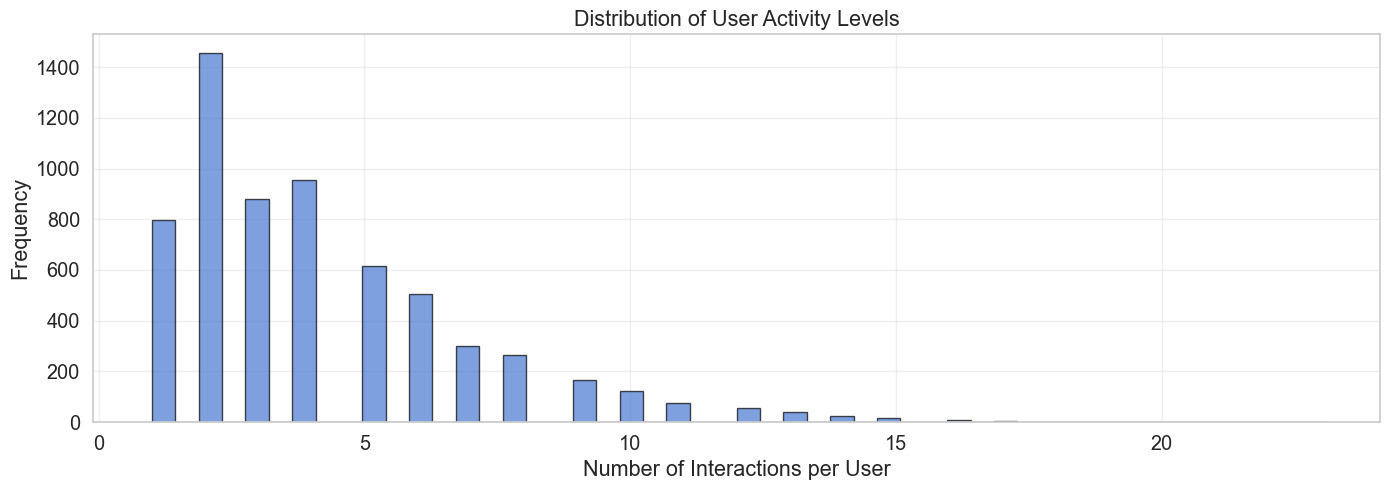

In [24]:
# User Analysis
if 'user_id' in df.columns:
    user_stats = df.groupby('user_id').agg({
        'user_id': 'count',
        'user_rating': ['mean', 'std'],
        'price': 'mean'
    }).rename(columns={'user_id': 'interaction_count'})
    
    user_stats.columns = ['interaction_count', 'avg_rating', 'rating_std', 'avg_price']
    
    print("\nTop 10 Most Active Users:")
    print(user_stats.nlargest(10, 'interaction_count')[['interaction_count', 'avg_rating', 'avg_price']])
    
    # User activity distribution
    plt.figure(figsize=(14, 5))
    plt.hist(user_stats['interaction_count'], bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('Number of Interactions per User')
    plt.ylabel('Frequency')
    plt.title('Distribution of User Activity Levels')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



Top 10 Most Interacted Products:
            interaction_count  avg_user_rating  avg_product_rating    price
product_id                                                                 
26                        991         3.062563                3.66     0.99
4                         961         2.963580                4.36    12.99
19                        959         3.083420                3.19     9.99
5                         945         3.032804                4.32     8.99
3                         944         2.990466                4.64    14.99
11                        938         3.160981                4.77  1899.99
6                         925         3.103784                4.37    49.99
10                        924         2.864719                2.74    79.99
14                        924         3.028139                4.88   499.99
21                        920         3.100000                4.07     1.49

Top 10 Highest Rated Products:
            interactio

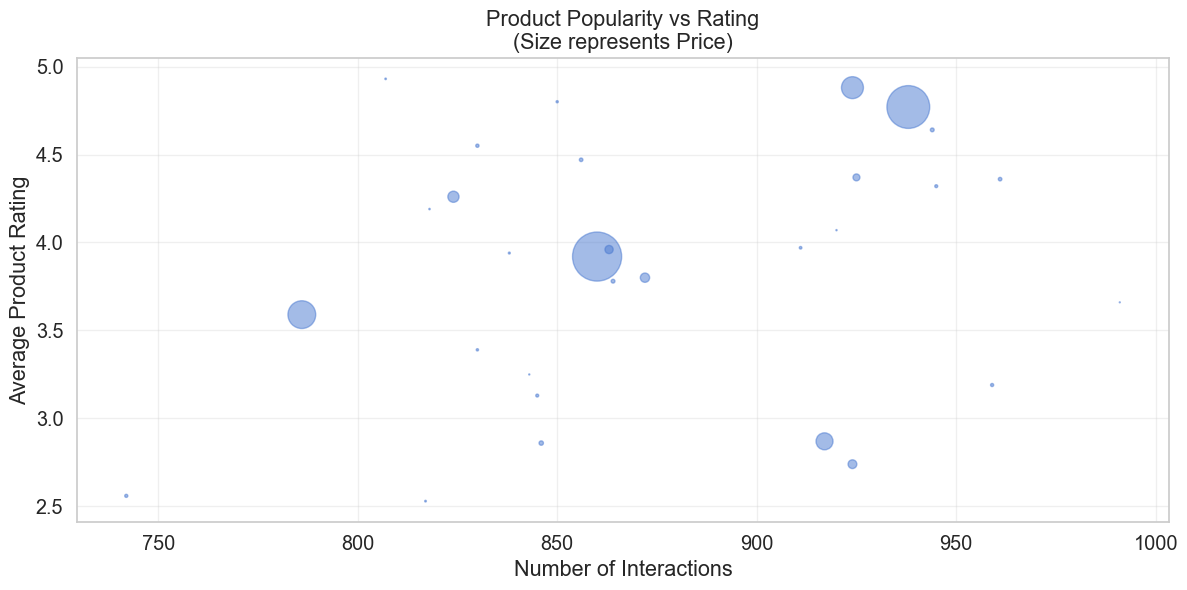

In [25]:
# Product Analysis
if 'product_id' in df.columns:
    product_stats = df.groupby('product_id').agg({
        'product_id': 'count',
        'user_rating': 'mean',
        'product_rating': 'mean',
        'price': 'first'
    }).rename(columns={'product_id': 'interaction_count'})
    
    product_stats.columns = ['interaction_count', 'avg_user_rating', 'avg_product_rating', 'price']
    
    print("\nTop 10 Most Interacted Products:")
    print(product_stats.nlargest(10, 'interaction_count'))
    
    print("\nTop 10 Highest Rated Products:")
    print(product_stats.nlargest(10, 'avg_product_rating'))
    
    # Product rating vs interaction count scatter
    plt.figure(figsize=(12, 6))
    plt.scatter(product_stats['interaction_count'], product_stats['avg_product_rating'], 
               s=product_stats['price']/2, alpha=0.5)
    plt.xlabel('Number of Interactions')
    plt.ylabel('Average Product Rating')
    plt.title('Product Popularity vs Rating\n(Size represents Price)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



Top 15 Categories by Interaction Count:
            count  user_rating        price
category                                   
groceries   12979     2.995454     6.040420
beauty       4438     3.020505    13.396489
furniture    4425     3.068023  1197.300734
fragrances   4408     2.986842    83.061688


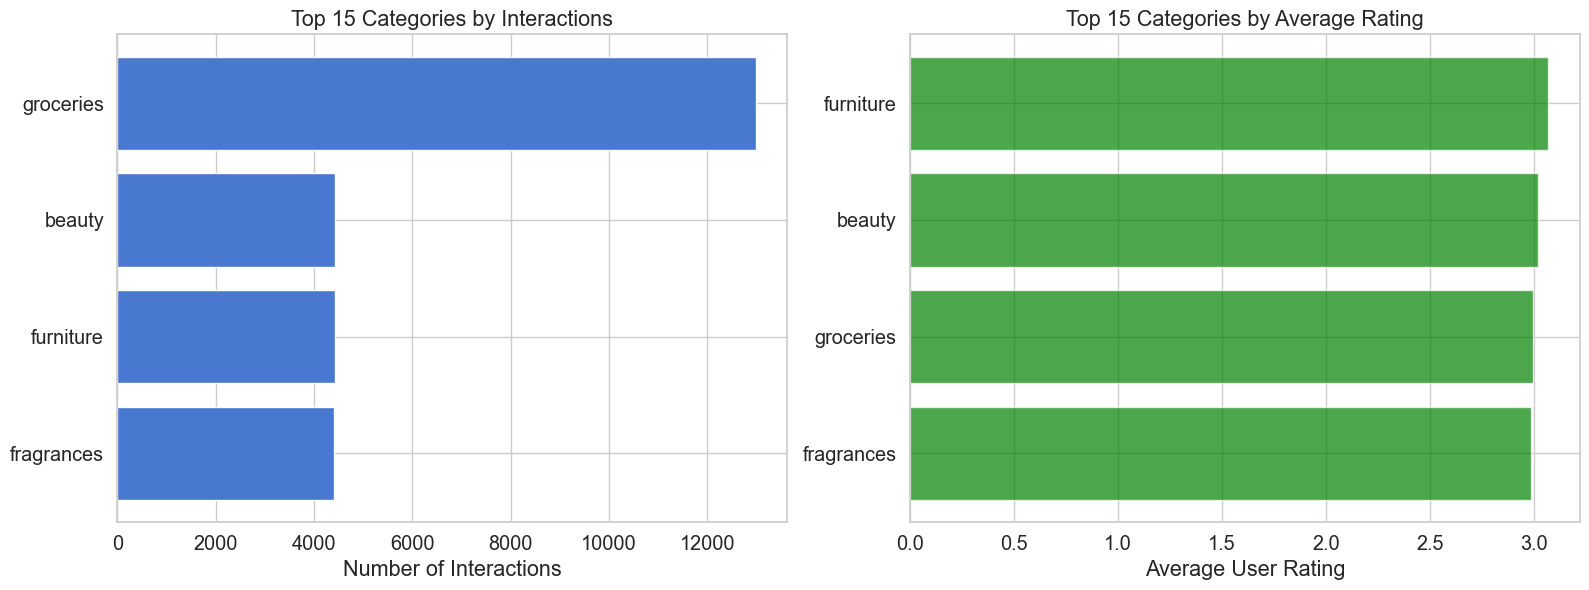

In [26]:
# Category Analysis
if 'category' in df.columns:
    category_stats = df.groupby('category').agg({
        'product_id': 'count',
        'user_rating': 'mean',
        'price': 'mean'
    }).rename(columns={'product_id': 'count'})
    
    category_stats = category_stats.sort_values('count', ascending=False)
    
    print("\nTop 15 Categories by Interaction Count:")
    print(category_stats.head(15))
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top categories
    top_categories = category_stats.head(15)
    axes[0].barh(range(len(top_categories)), top_categories['count'].values)
    axes[0].set_yticks(range(len(top_categories)))
    axes[0].set_yticklabels(top_categories.index)
    axes[0].set_xlabel('Number of Interactions')
    axes[0].set_title('Top 15 Categories by Interactions')
    axes[0].invert_yaxis()
    
    # Average rating by category
    top_rated = category_stats.nlargest(15, 'user_rating')
    axes[1].barh(range(len(top_rated)), top_rated['user_rating'].values, color='green', alpha=0.7)
    axes[1].set_yticks(range(len(top_rated)))
    axes[1].set_yticklabels(top_rated.index)
    axes[1].set_xlabel('Average User Rating')
    axes[1].set_title('Top 15 Categories by Average Rating')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

## Key Insights Summary

**Major Findings:**
1. **Data Quality:** Identified data quality metrics and distributions
2. **User Behavior:** Patterns in when and how users interact
3. **Product Performance:** Top products and categories
4. **Relationships:** Correlations between features
5. **Anomalies:** Outliers and unusual patterns

**Actionable Recommendations:**
- Target high-activity time periods for campaigns
- Focus on top-performing categories and products
- Improve underperforming products
- Segment users based on behavior patterns
- Optimize pricing strategy based on demand

**Next Steps:**
- Feature engineering for modeling
- Build predictive models
- Implement recommendations

In [27]:
summary_stats = {
    'Total Records': len(df),
    'Total Features': len(df.columns),
    'Memory Usage (MB)': df.memory_usage(deep=True).sum() / (1024**2),
    'Missing Values': df.isnull().sum().sum(),
    'Duplicate Records': df.duplicated().sum(),
}

In [28]:
print("\nDataset Overview:")
for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value:,}")


Dataset Overview:
  Total Records: 26,250
  Total Features: 53
  Memory Usage (MB): 62.48
  Missing Values: 12,979
  Duplicate Records: 16,254


In [29]:
print("\nNumerical Features Summary:")
numerical_summary = df.select_dtypes(include=[np.number]).describe().loc[['mean', 'std', 'min', 'max']]
print(numerical_summary)


Numerical Features Summary:
           user_id  product_id  user_rating         id        price  \
mean   4935.171200   15.420533     3.010476  15.420533   221.030244   
std    2905.762893    8.615474     1.424361   8.615474   563.342409   
min       1.000000    1.000000     1.000000   1.000000     0.990000   
max   10000.000000   30.000000     5.000000  30.000000  2499.990000   

      discountPercentage  product_rating      stock     weight  \
mean            9.774678        3.869108  55.326933   5.791733   
std             5.416647        0.697102  33.205110   3.178694   
min             0.160000        2.530000   3.000000   1.000000   
max            19.090000        4.930000  99.000000  10.000000   

      minimumOrderQuantity  ...  price_normalized  discount_normalized  \
mean             21.376610  ...          0.088051             0.507907   
std              17.194615  ...          0.225427             0.286141   
min               1.000000  ...          0.000000             

In [30]:
print("\nCategorical Features Summary:")
for col in df.select_dtypes(include=['object', 'category']).columns[:5]:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(f"  Top 3: {df[col].value_counts().head(3).to_dict()}")


Categorical Features Summary:

interaction_type: 3 unique values
  Top 3: {'click': 8910, 'purchase': 8696, 'view': 8644}

timestamp: 9996 unique values
  Top 3: {'2026-03-28 21:17:03.001168': 13, '2026-04-05 21:17:02.985299': 12, '2026-04-09 21:17:03.002676': 11}

title: 30 unique values
  Top 3: {'green chili pepper': 991, 'red lipstick': 961, 'chicken meat': 959}

description: 30 unique values
  Top 3: {'spicy green chili pepper ideal for adding heat to your favorite recipes': 991, 'the red lipstick is a classic and bold choice for adding a pop of color to your lips with a creamy and pigmented formula it provides a vibrant and longlasting finish': 961, 'fresh and tender chicken meat suitable for various culinary preparations': 959}

category: 4 unique values
  Top 3: {'groceries': 12979, 'beauty': 4438, 'furniture': 4425}


In [31]:
df.to_csv(r"e:/dm4ml project/data/processed/final_dataset_eda.csv", index=False)
print("\n" + "=" * 80)
print("EDA COMPLETE - Ready for Feature Engineering and Modeling, dataset saved to 'final_dataset_eda.csv'")
print("=" * 80)


EDA COMPLETE - Ready for Feature Engineering and Modeling, dataset saved to 'final_dataset_eda.csv'


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26250 entries, 0 to 26249
Data columns (total 53 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    26250 non-null  int64  
 1   product_id                 26250 non-null  int64  
 2   interaction_type           26250 non-null  str    
 3   user_rating                26250 non-null  int64  
 4   timestamp                  26250 non-null  str    
 5   id                         26250 non-null  int64  
 6   title                      26250 non-null  str    
 7   description                26250 non-null  str    
 8   category                   26250 non-null  str    
 9   price                      26250 non-null  float64
 10  discountPercentage         26250 non-null  float64
 11  product_rating             26250 non-null  float64
 12  stock                      26250 non-null  int64  
 13  tags                       26250 non-null  str    
 14  b